# 3. T-s Diagram for the sCO₂ Recompression Cycle

## 3.1 Problem statement

The recompression cycle is the workhorse layout for sCO₂ power cycles
coupled to advanced reactors: it splits the low-pressure stream so that
part bypasses the low-temperature recuperator, eliminating the
"pinch-point" caused by the asymmetric heat capacities of the cold
high-density stream and the hot low-density stream.

Visualising it on a T-s diagram is the fastest way to develop intuition
for *why* recompression is necessary.

## 3.2 Mathematical description

The cycle has six conventional state points:

| Point | Description |
|-------|-------------|
| 1 | Main compressor inlet (~35 °C, 8 MPa) |
| 2 | Main compressor outlet (~70 °C, 25 MPa) |
| 3 | After low-T recuperator (~150 °C, 25 MPa) |
| 4 | After high-T recuperator + reactor (~550 °C, 25 MPa) |
| 5 | Turbine outlet (~430 °C, 8 MPa) |
| 6 | After high-T recuperator hot side (~200 °C, 8 MPa) |

Net cycle efficiency:

$$
\eta_{\rm cycle} \;=\;
\frac{\dot W_{\rm turbine} - \dot W_{\rm main} - \dot W_{\rm recompressor}}
     {\dot Q_{\rm reactor}}
$$

## 3.3 Code — sketch the cycle

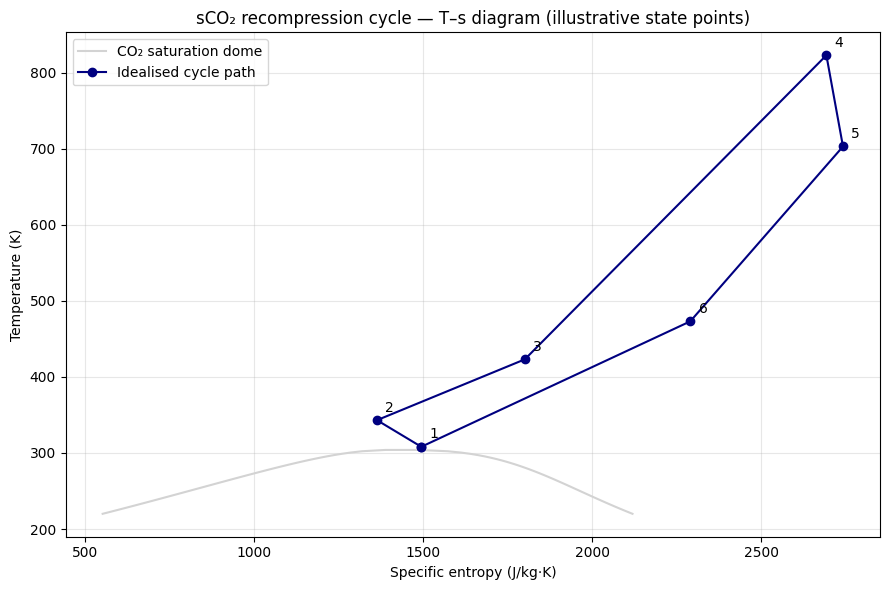

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

P_low  = 8.0e6
P_high = 25.0e6
T_max  = 550 + 273.15
T_min  = 35  + 273.15

# Saturation dome for context (sub-critical part only)
T_sat = np.linspace(220, 304, 50)
s_liq = [CP.PropsSI("S", "T", t, "Q", 0, "CO2") for t in T_sat]
s_vap = [CP.PropsSI("S", "T", t, "Q", 1, "CO2") for t in T_sat]

# Approximate cycle states (idealised — no irreversibility shown here)
points = []
points.append(("1", T_min,  P_low,  CP.PropsSI("S", "T", T_min,  "P", P_low,  "CO2")))
points.append(("2", 70  + 273.15, P_high, CP.PropsSI("S", "T", 70 + 273.15, "P", P_high, "CO2")))
points.append(("3", 150 + 273.15, P_high, CP.PropsSI("S", "T", 150 + 273.15, "P", P_high, "CO2")))
points.append(("4", T_max,  P_high, CP.PropsSI("S", "T", T_max, "P", P_high, "CO2")))
points.append(("5", 430 + 273.15, P_low,  CP.PropsSI("S", "T", 430 + 273.15, "P", P_low, "CO2")))
points.append(("6", 200 + 273.15, P_low,  CP.PropsSI("S", "T", 200 + 273.15, "P", P_low, "CO2")))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(s_liq + s_vap[::-1], list(T_sat) + list(T_sat[::-1]),
        color="lightgrey", label="CO₂ saturation dome")

s_arr = [p[3] for p in points]
T_arr = [p[1] for p in points]
ax.plot(s_arr + [s_arr[0]], T_arr + [T_arr[0]], "o-", color="navy",
        markersize=6, label="Idealised cycle path")
for label, T_pt, _, s_pt in points:
    ax.annotate(label, (s_pt, T_pt), textcoords="offset points", xytext=(6, 6))

ax.set_xlabel("Specific entropy (J/kg·K)")
ax.set_ylabel("Temperature (K)")
ax.set_title("sCO₂ recompression cycle — T–s diagram (illustrative state points)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3.4 Engineering implication

- The wide horizontal sweep at low pressure (state 5 → 6) is where the
  high-temperature recuperator extracts heat — by far the largest
  internal heat-transfer duty in the cycle
- The recompression branch (not shown explicitly here — it would split off
  before state 1 and rejoin at state 3) eliminates the pinch point that
  would otherwise dominate the low-T recuperator design
- **The recompression-cycle Modelica model (Phase 3, § 3.3) builds this
  diagram directly from solver output** — see `Cycles/RecompressionCycle.mo`
  in the upcoming Modelica library

## 3.5 Validation status

This notebook is a *pedagogical sketch* — the cycle states are illustrative,
not the result of a converged solver. The Phase 3 Modelica library will
publish a notebook (`05_dostal2004_validation.md`) that reproduces the
efficiency curves from Dostal 2004 thesis Figure 6.5.

## 3.6 References

- Dostal (2004), MIT thesis — Figures 6.4 and 6.5 (recompression efficiency curves)
- Sandia OSTI reports on the 10 MWe sCO₂ test loop — operating-point T-s data